In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc
import seaborn as sns
from PIL import Image

In [ ]:
base_path=r"data/raw/MURA-v1.1"
final_base=r"data/processed"
for split in ["train","val","test"]:
    for label in ["fractured","not_fractured"]:
        os.makedirs(os.path.join(final_base, split, label),exist_ok=True)

In [ ]:
all_images=[]
labels=[]
for split_folder in ["train","valid"]:
    for root, _, files in os.walk(os.path.join(base_path,split_folder)):
        for f in files:
            if f.lower().endswith((".png",".jpg",".jpeg")):
                all_images.append(os.path.join(root,f))
                if "positive" in root.lower():
                    labels.append("fractured")
                else:
                    labels.append("not_fractured")
print("Total images found:",len(all_images))

In [ ]:
train_files,temp,train_labels,temp_labels=train_test_split(all_images,labels,test_size=0.30,random_state=42,stratify=labels)
val_files,test_files,val_labels,test_labels=train_test_split(temp,temp_labels,test_size=0.6666,random_state=42,stratify=temp_labels)
print("Train:",len(train_files))
print("Validation:",len(val_files))
print("Test:",len(test_files))

In [ ]:
def copy_files(file_list,label_list,target_base):
    counter=1
    for f,label in zip(file_list,label_list):
        ext=os.path.splitext(f)[1]
        new_name=f"{counter:06d}{ext}"
        dst=os.path.join(target_base,label,new_name)
        shutil.copy(f,dst)
        counter+=1
copy_files(train_files, train_labels, os.path.join(final_base,"train"))
copy_files(val_files, val_labels, os.path.join(final_base,"val"))
copy_files(test_files, test_labels, os.path.join(final_base,"test"))
print("Done! Dataset split with labels preserved.")

In [17]:
source_dir="/kaggle/input/dataset/dataset_split"
final_base="/kaggle/working/dataset_cleaned"
shutil.copytree(source_dir,final_base,dirs_exist_ok=True)
print("Copied dataset to writable folder:",final_base)

Copied dataset to writable folder: /kaggle/working/dataset_cleaned


In [18]:
def remove_corrupted_images(folder):
    removed=0
    for root,dirs,files in os.walk(folder):
        for file in files:
            path=os.path.join(root,file)
            try:
                img=Image.open(path)
                img.verify()
            except:
                print("Deleting corrupted:",path)
                os.remove(path)
                removed += 1
    print("Total deleted:",removed)
remove_corrupted_images(os.path.join(final_base,"train"))
remove_corrupted_images(os.path.join(final_base,"val"))
remove_corrupted_images(os.path.join(final_base,"test"))

Deleting corrupted: /kaggle/working/dataset_cleaned/train/not_fractured/006730.png
Deleting corrupted: /kaggle/working/dataset_cleaned/train/not_fractured/006608.png
Deleting corrupted: /kaggle/working/dataset_cleaned/train/not_fractured/027220.png
Deleting corrupted: /kaggle/working/dataset_cleaned/train/not_fractured/023113.png
Total deleted: 4
Total deleted: 0
Total deleted: 0


In [19]:
train_dir=os.path.join(final_base,"train")
val_dir=os.path.join(final_base,"val")
test_dir=os.path.join(final_base,"test")

In [20]:
IMAGE_SIZE=(224,224)
BATCH_SIZE=16
EPOCHS=25
LR=1e-4

In [21]:
train_datagen=ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,rotation_range=10,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,zoom_range=0.1,shear_range=0.1)
val_datagen=ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
train_generator=train_datagen.flow_from_directory(train_dir,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='binary')
val_generator=val_datagen.flow_from_directory(val_dir,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='binary')

Found 28002 images belonging to 2 classes.
Found 4001 images belonging to 2 classes.


In [22]:
base_model=tf.keras.applications.EfficientNetV2L(include_top=False,weights='imagenet',input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3))
base_model.trainable=False
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation='relu')(x)
output=Dense(1,activation='sigmoid')(x)
model=Model(inputs=base_model.input,outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR),loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      9,216 │ stem_activation[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │        128 │ block1a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 32)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      9,216 │ block1a_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │        128 │ block1b_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 32)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_co… │ (None, 112, 112,  │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_bn  │ (None, 112, 112,  │        128 │ block1c_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_ac… │ (None, 112, 112,  │          0 │ block1c_project_

 Total params: 117,910,945 (449.79 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [23]:
checkpoint=ModelCheckpoint("MURA_EfficientNetV2L.h5",monitor='val_loss',save_best_only=True,verbose=1)
early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,verbose=1)

In [25]:
history=model.fit(train_generator,validation_data=val_generator,epochs=EPOCHS,callbacks=[checkpoint,early_stop])

Epoch 1/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6465 - loss: 0.6280
Epoch 1: val_loss improved from inf to 0.57383, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 617s 298ms/step - accuracy: 0.6465 - loss: 0.6280 - val_accuracy: 0.7091 - val_loss: 0.5738
Epoch 2/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7049 - loss: 0.5725
Epoch 2: val_loss improved from 0.57383 to 0.55941, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 461s 263ms/step - accuracy: 0.7049 - loss: 0.5725 - val_accuracy: 0.7201 - val_loss: 0.5594
Epoch 3/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7208 - loss: 0.5554
Epoch 3: val_loss improved from 0.55941 to 0.55025, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 446s 255ms/step - accuracy: 0.7208 - loss: 0.5554 - val_accuracy: 0.7286 - val_loss: 0.5503
Epoch 4/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7249 - loss: 0.5551
Epoch 4: val_loss improved from 0.55025 to 0.54672, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 447s 255ms/step - accuracy: 0.7249 - loss: 0.5551 - val_accuracy: 0.7268 - val_loss: 0.5467
Epoch 5/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7304 - loss: 0.5442
Epoch 5: val_loss improved from 0.54672 to 0.53875, saving model to 23F6109_MURA_EfficientNetV2L.h5


...

1751/1751 ━━━━━━━━━━━━━━━━━━━━ 447s 255ms/step - accuracy: 0.7566 - loss: 0.5053 - val_accuracy: 0.7528 - val_loss: 0.5133
Epoch 18/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7507 - loss: 0.5078
Epoch 18: val_loss did not improve from 0.51327
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 435s 248ms/step - accuracy: 0.7507 - loss: 0.5078 - val_accuracy: 0.7476 - val_loss: 0.5268
Epoch 19/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7699 - loss: 0.4948
Epoch 19: val_loss did not improve from 0.51327
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 438s 250ms/step - accuracy: 0.7699 - loss: 0.4948 - val_accuracy: 0.7483 - val_loss: 0.5176
Epoch 20/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7641 - loss: 0.4969
Epoch 20: val_loss improved from 0.51327 to 0.51312, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 438s 250ms/step - accuracy: 0.7641 - loss: 0.4969 - val_accuracy: 0.7548 - val_loss: 0.5131
Epoch 21/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7667 - loss: 0.4966
Epoch 21: val_loss did not improve from 0.51312
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 435s 248ms/step - accuracy: 0.7666 - loss: 0.4966 - val_accuracy: 0.7508 - val_loss: 0.5139
Epoch 22/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7667 - loss: 0.4870
Epoch 22: val_loss improved from 0.51312 to 0.51199, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 434s 248ms/step - accuracy: 0.7667 - loss: 0.4870 - val_accuracy: 0.7561 - val_loss: 0.5120
Epoch 23/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7692 - loss: 0.4872
Epoch 23: val_loss improved from 0.51199 to 0.51059, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 437s 249ms/step - accuracy: 0.7692 - loss: 0.4873 - val_accuracy: 0.7613 - val_loss: 0.5106
Epoch 24/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7676 - loss: 0.4910
Epoch 24: val_loss improved from 0.51059 to 0.50920, saving model to 23F6109_MURA_EfficientNetV2L.h5


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 441s 252ms/step - accuracy: 0.7676 - loss: 0.4910 - val_accuracy: 0.7613 - val_loss: 0.5092
Epoch 25/25
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7616 - loss: 0.4964
Epoch 25: val_loss did not improve from 0.50920
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 433s 247ms/step - accuracy: 0.7616 - loss: 0.4964 - val_accuracy: 0.7501 - val_loss: 0.5148
Restoring model weights from the end of the best epoch: 24.


In [27]:
test_datagen=ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input)
test_generator=test_datagen.flow_from_directory(test_dir,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='binary',shuffle=False)
test_loss, test_acc=model.evaluate(test_generator)
print(f"Test Accuracy:{test_acc:.4f}")

Found 8002 images belonging to 2 classes.
501/501 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.6577 - loss: 0.6236
Test Accuracy: 0.7553


501/501 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step


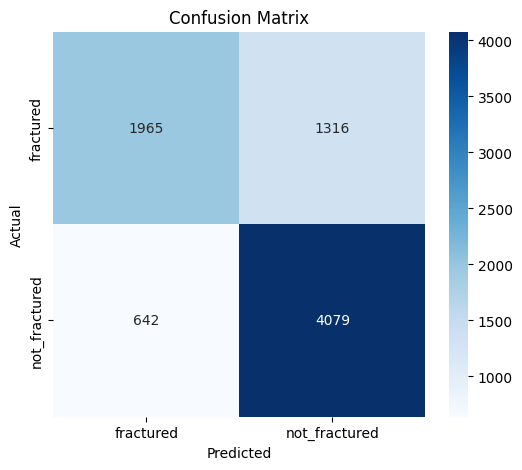

Classification Report:

               precision    recall  f1-score   support

    fractured       0.75      0.60      0.67      3281
not_fractured       0.76      0.86      0.81      4721

     accuracy                           0.76      8002
    macro avg       0.75      0.73      0.74      8002
 weighted avg       0.76      0.76      0.75      8002



In [28]:
y_pred_prob=model.predict(test_generator)
y_pred=(y_pred_prob>0.5).astype(int)
y_true=test_generator.classes
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=test_generator.class_indices.keys(),yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("Classification Report:\n")
print(classification_report(y_true,y_pred,target_names=test_generator.class_indices.keys()))

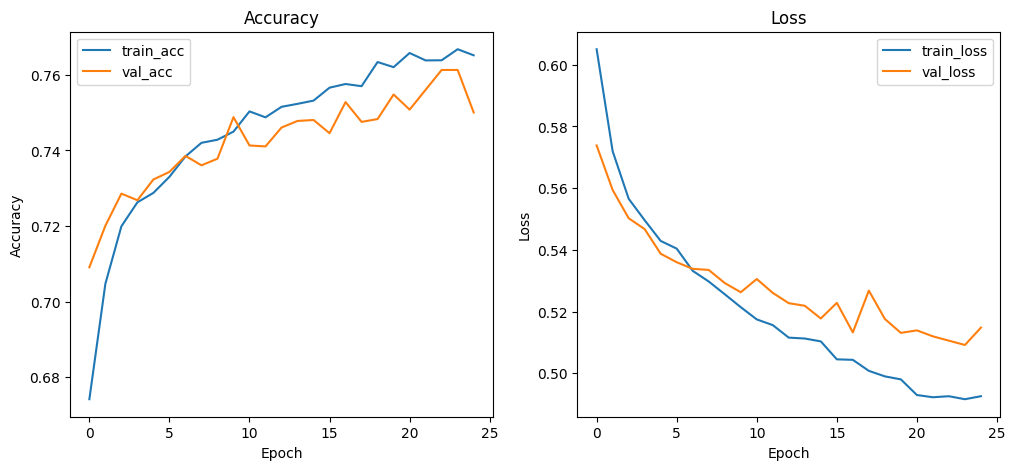

In [29]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


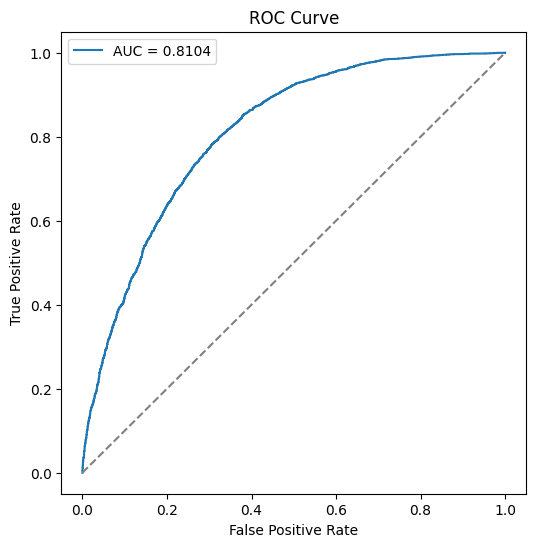

In [30]:
fpr,tpr,thresholds=roc_curve(y_true,y_pred_prob)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()